Meu portfólio: https://pedrovsd.github.io/Portfolio/

# Clustering

Dataset: https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset/data

In [ ]:
!pip install kmodes

In [ ]:
import kagglehub
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import seaborn as sns

In [ ]:
# Download latest version
path = kagglehub.dataset_download("mosapabdelghany/student-performance-factors-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-factors-dataset' dataset.
Path to dataset files: /kaggle/input/student-performance-factors-dataset


In [ ]:
dataset = pd.read_csv('/kaggle/input/student-performance-factors-dataset/StudentPerformanceFactors.csv')

In [ ]:
dataset.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

# Vendo quais valores estão ausentes

In [ ]:
for column in dataset.columns:
    if dataset[column].isnull().sum() > 0:
        print(f"Coluna '{column}': {dataset[column].isnull().sum()} valores ausentes")
        #isnull() veririfca se o valor é nulo, esse isnull() trata True como 1 e False como 0, por isso vamos somando para saber o total
    else:
        print(f"Coluna '{column}': Não há valores ausentes")

Coluna 'Hours_Studied': Não há valores ausentes
Coluna 'Attendance': Não há valores ausentes
Coluna 'Parental_Involvement': Não há valores ausentes
Coluna 'Access_to_Resources': Não há valores ausentes
Coluna 'Extracurricular_Activities': Não há valores ausentes
Coluna 'Sleep_Hours': Não há valores ausentes
Coluna 'Previous_Scores': Não há valores ausentes
Coluna 'Motivation_Level': Não há valores ausentes
Coluna 'Internet_Access': Não há valores ausentes
Coluna 'Tutoring_Sessions': Não há valores ausentes
Coluna 'Family_Income': Não há valores ausentes
Coluna 'Teacher_Quality': 78 valores ausentes
Coluna 'School_Type': Não há valores ausentes
Coluna 'Peer_Influence': Não há valores ausentes
Coluna 'Physical_Activity': Não há valores ausentes
Coluna 'Learning_Disabilities': Não há valores ausentes
Coluna 'Parental_Education_Level': 90 valores ausentes
Coluna 'Distance_from_Home': 67 valores ausentes
Coluna 'Gender': Não há valores ausentes
Coluna 'Exam_Score': Não há valores ausentes


# Vendo os tipos dos valores das colunas que possuem valores ausentes

In [ ]:
Parental_Education_Level_types = []

for value in dataset['Parental_Education_Level']:
    if value not in Parental_Education_Level_types:
        Parental_Education_Level_types.append(value)

print('Parental_Education_Level')
print(Parental_Education_Level_types)
print("-"*50)

Distance_from_Home_types = []

for value in dataset['Distance_from_Home']:
    if value not in Distance_from_Home_types:
        Distance_from_Home_types.append(value)
print("Distance_from_Home")
print(Distance_from_Home_types)
print("-"*50)

Teacher_Quality_types = []

for value in dataset['Teacher_Quality']:
  if value not in Teacher_Quality_types:
    Teacher_Quality_types.append(value)
print("Teacher_Quality")
print(Teacher_Quality_types)
# 'Teacher_Quality': 78 missing values(low,medium,high), 'Parental_Education_Level': 90 missing values(High School, College, Postgraduate), 'Distance_from_Home': 67 missing values('Near', 'Moderate', 'Far')

Parental_Education_Level
['High School', 'College', 'Postgraduate', nan]
--------------------------------------------------
Distance_from_Home
['Near', 'Moderate', 'Far', nan]
--------------------------------------------------
Teacher_Quality
['Medium', 'High', 'Low', nan]


## Aqui podemos Usar duas abordagens, preencher os faltantes com 'não informado'. Ou usar o KNN que ele vai tentar arupar da mesma forma.

In [ ]:
#fillna() preenche com um valor passado como argumento
dataset['Teacher_Quality'] = dataset['Teacher_Quality'].fillna('Not informed')
dataset['Parental_Education_Level'] = dataset['Parental_Education_Level'].fillna('Not informed')
dataset['Distance_from_Home'] = dataset['Distance_from_Home'].fillna('Not informed')

## Verificando novamente

In [ ]:
for column in dataset.columns:
    if dataset[column].isnull().sum() > 0:
        print(f"Column '{column}': {dataset[column].isnull().sum()} missing values")
    else:
        print(f"Column '{column}': No missing values")

Column 'Hours_Studied': No missing values
Column 'Attendance': No missing values
Column 'Parental_Involvement': No missing values
Column 'Access_to_Resources': No missing values
Column 'Extracurricular_Activities': No missing values
Column 'Sleep_Hours': No missing values
Column 'Previous_Scores': No missing values
Column 'Motivation_Level': No missing values
Column 'Internet_Access': No missing values
Column 'Tutoring_Sessions': No missing values
Column 'Family_Income': No missing values
Column 'Teacher_Quality': No missing values
Column 'School_Type': No missing values
Column 'Peer_Influence': No missing values
Column 'Physical_Activity': No missing values
Column 'Learning_Disabilities': No missing values
Column 'Parental_Education_Level': No missing values
Column 'Distance_from_Home': No missing values
Column 'Gender': No missing values
Column 'Exam_Score': No missing values


In [ ]:
for column in dataset.columns:
  print(f"Column '{column}': {dataset[column].unique()}")

Column 'Hours_Studied': [23 19 24 29 25 17 21  9 10 14 22 15 12 20 11 13 16 18 31  8 26 28  4 35
 27 33 36 43 34  1 30  7 32  6 38  5  3  2 39 37 44]
Column 'Attendance': [ 84  64  98  89  92  88  78  94  80  97  83  82  68  60  70  75  99  74
  65  62  91  90  66  69  72  63  61  86  77  71  67  87  73  96 100  81
  95  79  85  76  93]
Column 'Parental_Involvement': ['Low' 'Medium' 'High']
Column 'Access_to_Resources': ['High' 'Medium' 'Low']
Column 'Extracurricular_Activities': ['No' 'Yes']
Column 'Sleep_Hours': [ 7  8  6 10  9  5  4]
Column 'Previous_Scores': [ 73  59  91  98  65  89  68  50  80  71  88  87  97  72  74  70  82  58
  99  84 100  75  54  90  94  51  57  66  96  93  56  52  63  79  81  69
  95  60  92  77  62  85  78  64  76  55  86  61  53  83  67]
Column 'Motivation_Level': ['Low' 'Medium' 'High']
Column 'Internet_Access': ['Yes' 'No']
Column 'Tutoring_Sessions': [0 2 1 3 4 5 6 7 8]
Column 'Family_Income': ['Low' 'Medium' 'High']
Column 'Teacher_Quality': ['Medium' '

# Separando valores numéricos e categóricos

In [ ]:
valores_numericos = []
valores_categoricos = []
for column in dataset.columns:
    if dataset[column].dtype == 'int64' or dataset[column].dtype == 'float64':
        valores_numericos.append(column)
    else:
        valores_categoricos.append(column)
print("Valores numéricos:\n")
for i in valores_numericos:
    print(i)
print('-------------------')
print("Valores categóricos:\n")
for j in valores_categoricos:
    print(j)

Valores numéricos:

Hours_Studied
Attendance
Sleep_Hours
Previous_Scores
Tutoring_Sessions
Physical_Activity
Exam_Score
-------------------
Valores categóricos:

Parental_Involvement
Access_to_Resources
Extracurricular_Activities
Motivation_Level
Internet_Access
Family_Income
Teacher_Quality
School_Type
Peer_Influence
Learning_Disabilities
Parental_Education_Level
Distance_from_Home
Gender


# Colunas numéricas normalizadas utilizando a z-score -> (n-x̅)/σ

In [ ]:
padronizador = StandardScaler()
colunas_numericas_padronizadas = padronizador.fit_transform(dataset[valores_numericos])
dataset_padronizado = pd.DataFrame(colunas_numericas_padronizadas, columns=valores_numericos)
print(dataset_padronizado)

      Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
0          0.504942    0.348375    -0.019796        -0.143800   
1         -0.162822   -1.383736     0.661399        -1.116110   
2          0.671882    1.560853    -0.019796         1.106313   
3          1.506587    0.781403     0.661399         1.592469   
4         -0.162822    1.041220    -0.700990        -0.699406   
...             ...         ...          ...              ...   
6602       0.838823   -0.950708    -0.019796         0.064552   
6603       0.504942   -0.344469     0.661399         0.411806   
6604       0.004119    0.868009    -0.700990        -0.699406   
6605      -1.665291    0.521587    -0.700990         1.106313   
6606      -0.830586   -1.123919     1.342594         1.314666   

      Tutoring_Sessions  Physical_Activity  Exam_Score  
0             -1.213934           0.031411   -0.060578  
1              0.411451           1.001199   -1.602931  
2              0.411451           1.001199    1.

In [ ]:
dataset_padronizado = dataset_padronizado.reset_index(drop=True)
df_categorico = dataset[valores_categoricos].reset_index(drop=True)
df_pronto = pd.concat([dataset_padronizado, df_categorico], axis=1)

In [ ]:
df_pronto.head(10)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,0.504942,0.348375,-0.019796,-0.143800,-1.213934,0.031411,-0.060578,Low,High,No,Low,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
1,-0.162822,-1.383736,0.661399,-1.116110,0.411451,1.001199,-1.602931,Low,Medium,No,Low,Yes,Medium,Medium,Public,Negative,No,College,Moderate,Female
2,0.671882,1.560853,-0.019796,1.106313,0.411451,1.001199,1.738833,Medium,Medium,Yes,Medium,Yes,Medium,Medium,Public,Neutral,No,Postgraduate,Near,Male
3,1.506587,0.781403,0.661399,1.592469,-0.401242,1.001199,0.967657,Low,Medium,Yes,Medium,Yes,Medium,Medium,Public,Negative,No,High School,Moderate,Male
4,-0.162822,1.041220,-0.700990,-0.699406,1.224144,1.001199,0.710598,Medium,Medium,Yes,Medium,Yes,Medium,High,Public,Neutral,No,College,Near,Female
5,-0.162822,0.694798,0.661399,0.967412,1.224144,0.031411,0.967657,Medium,Medium,Yes,Medium,Yes,Medium,Medium,Public,Positive,No,Postgraduate,Near,Male
6,1.506587,0.348375,-0.019796,-0.491054,-0.401242,-0.938377,-0.060578,Medium,Low,Yes,Low,Yes,Low,Medium,Private,Neutral,No,High School,Moderate,Male
7,0.838823,-0.171258,-0.700990,-1.741167,-0.401242,-0.938377,-0.317637,Low,High,Yes,Medium,Yes,High,High,Public,Negative,No,High School,Far,Male
8,-0.496704,1.214431,-0.700990,0.342355,-1.213934,-1.908165,0.453539,Medium,High,No,High,Yes,Medium,Low,Private,Neutral,No,College,Near,Male
9,0.504942,1.560853,0.661399,-0.282701,-1.213934,1.970988,1.224715,Medium,Medium,Yes,Medium,Yes,High,High,Public,Positive,No,High School,Moderate,Male


# Aplicando o K-prototypes

In [ ]:
df_pronto_array = df_pronto.values #Convertendo pandas para numpy
indices_cateoricos = list(range(len(valores_numericos), df_pronto.shape[1])) # Seleciona o índice de cada coluna categórica para o cluster

custos = []
K_range = range(2, 21)

for k in K_range:
    print(f"Teste com o valor de {k} para K")
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=10, random_state=42, n_jobs=-1)
    clusters = kproto.fit_predict(df_pronto_array, categorical=indices_cateoricos)
    custos.append(kproto.cost_)

Teste com o valor de 2 para K


# Gráfico no número de cluster pelo custo daquele cluster

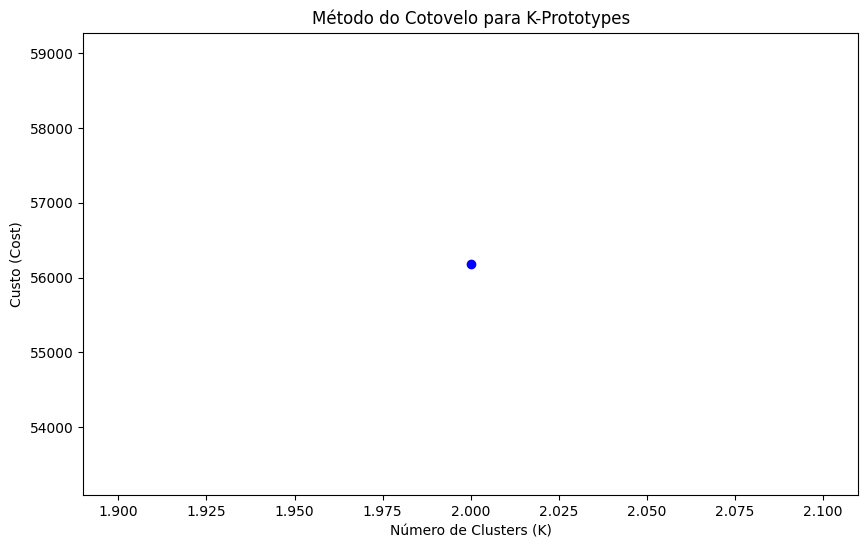

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(K_range, custos, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Custo (Cost)')
plt.title('Método do Cotovelo para K-Prototypes')
plt.show()

# Escolhendo o K para continuar

In [ ]:
K_ESCOLHIDO = 4
kproto_final = KPrototypes(n_clusters=K_ESCOLHIDO, init='Cao', n_init=10, random_state=42,n_jobs=-1)
clusters = kproto_final.fit_predict(df_pronto_array, categorical=indices_cateoricos)

In [ ]:
df_pronto['Cluster'] = clusters

# Vendo a distribuição de cada variável por cluster

In [ ]:
print("\n--- Distribuição Categórica por Cluster ---")
for col in valores_categoricos:
    print(f"\nAnálise da coluna: {col}")
    # 'normalize="index"' mostra a % de cada categoria DENTRO de cada cluster
    crosstab_norm = pd.crosstab(df_pronto['Cluster'], df_pronto[col], normalize='index') * 100
    crosstab_norm = crosstab_norm.round(1) # Arredondar para 1 casa decimal
    print(crosstab_norm)


--- Distribuição Categórica por Cluster ---

Análise da coluna: Parental_Involvement
Parental_Involvement  High   Low  Medium
Cluster                                 
0                     29.1  19.8    51.1
1                     27.4  20.9    51.7
2                     29.9  20.9    49.1
3                     26.9  21.6    51.5
4                     31.9  17.7    50.4

Análise da coluna: Access_to_Resources
Access_to_Resources  High   Low  Medium
Cluster                                
0                    28.8  21.3    49.8
1                    28.0  22.4    49.7
2                    27.3  20.4    52.3
3                    29.2  19.4    51.4
4                    36.1  15.5    48.4

Análise da coluna: Extracurricular_Activities
Extracurricular_Activities    No   Yes
Cluster                               
0                           42.0  58.0
1                           42.4  57.6
2                           39.4  60.6
3                           40.5  59.5
4                         

# Aplicando o PCA

In [ ]:
df_num_vis = dataset_padronizado
df_cat_vis = df_categorico

encoder = OneHotEncoder(sparse_output=False)
df_cat_vis_encoded = encoder.fit_transform(df_cat_vis)

In [ ]:
dados_visualizacao_pronto = np.concatenate((df_num_vis.values, df_cat_vis_encoded), axis=1)

In [ ]:
pca = PCA(n_components=10) # Reduzir os componentes para visualização em 2D
dados_pca = pca.fit_transform(dados_visualizacao_pronto)

df_pca = pd.DataFrame(data = dados_pca, columns = ['Componente Principal 1', 'Componente Principal 2', 'Componente Principal 3', 'Componente Principal 4', 'Componente Principal 5', 'Componente Principal 6', 'Componente Principal 7', 'Componente Principal 8', 'Componente Principal 9', 'Componente Principal 10'])
df_pca['Cluster'] = df_pronto['Cluster'] # Adicionar os clusters encontrados anteriormente

# Visualização dos Clusters após PCA

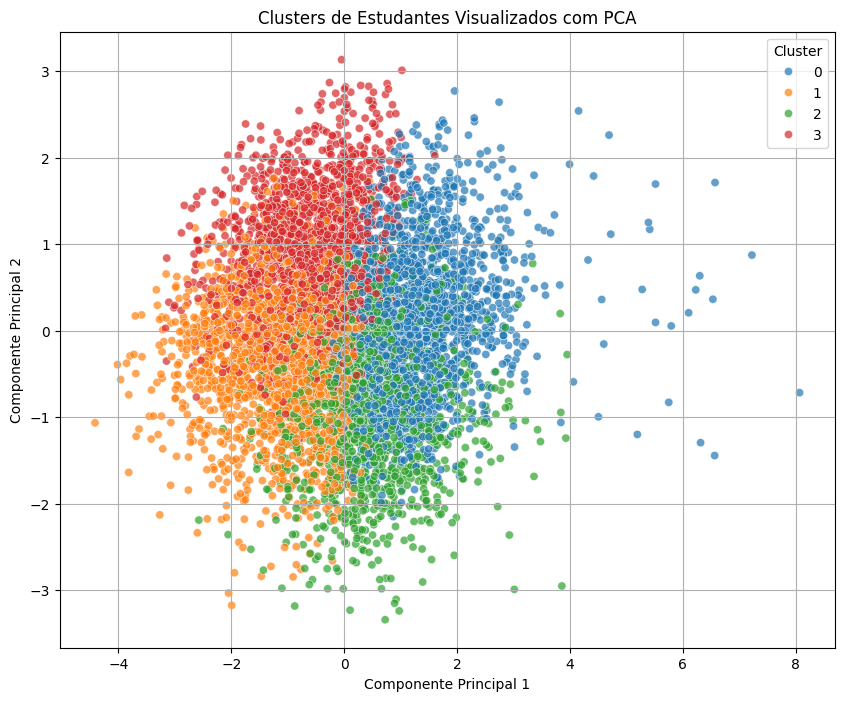

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='Cluster',
    palette=sns.color_palette('tab10', n_colors=len(df_pca['Cluster'].unique())),
    data=df_pca,
    legend='full',
    alpha=0.7
)
plt.title('Clusters de Estudantes Visualizados com PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

In [ ]:
print(f"Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

Variância explicada pelos 2 componentes: 63.51%


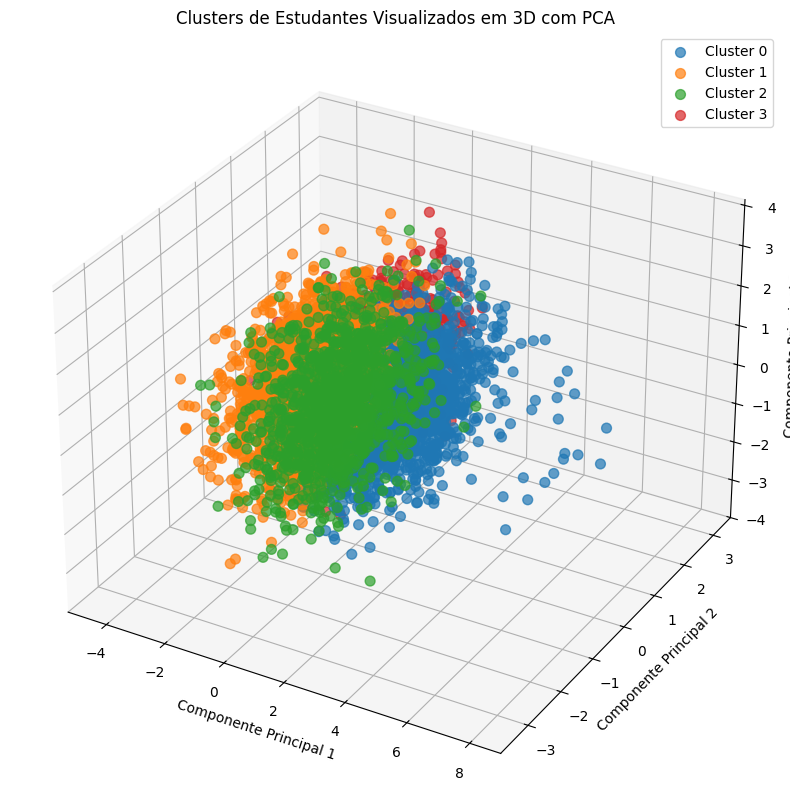

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Get unique cluster labels for coloring
cluster_labels = df_pca['Cluster'].unique()
cluster_labels.sort() # Ensure consistent ordering

# Define a colormap (e.g., 'tab10' for up to 10 clusters)
palette = sns.color_palette('tab10', n_colors=len(cluster_labels))

for i, cluster in enumerate(cluster_labels):
    subset = df_pca[df_pca['Cluster'] == cluster]
    ax.scatter(
        subset['Componente Principal 1'],
        subset['Componente Principal 2'],
        subset['Componente Principal 3'],
        c=[palette[i]], # Use a single color for all points in this cluster
        label=f'Cluster {cluster}',
        s=50, # Size of points
        alpha=0.7 # Transparency
    )

ax.set_title('Clusters de Estudantes Visualizados em 3D com PCA')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.legend()
ax.grid(True)
plt.show()

# Média dos dados numéricos por cluster

In [ ]:
print("\n--- Análise Numérica por Cluster (Médias) ---")
print(df_pronto.groupby('Cluster')[valores_numericos].mean().round(2))


--- Análise Numérica por Cluster (Médias) ---
         Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
Cluster                                                            
0                -0.49        0.97        -0.03            -0.50   
1                -0.18       -0.89         0.07            -0.85   
2                 0.04        0.07        -0.05            -0.12   
3                -0.19       -0.71         0.01             0.93   
4                 0.94        0.73        -0.01             0.50   

         Tutoring_Sessions  Physical_Activity  Exam_Score  
Cluster                                                    
0                    -0.34              -0.22        0.14  
1                    -0.29               0.14       -0.90  
2                     1.62               0.19        0.28  
3                    -0.32              -0.11       -0.47  
4                    -0.18               0.07        1.20  


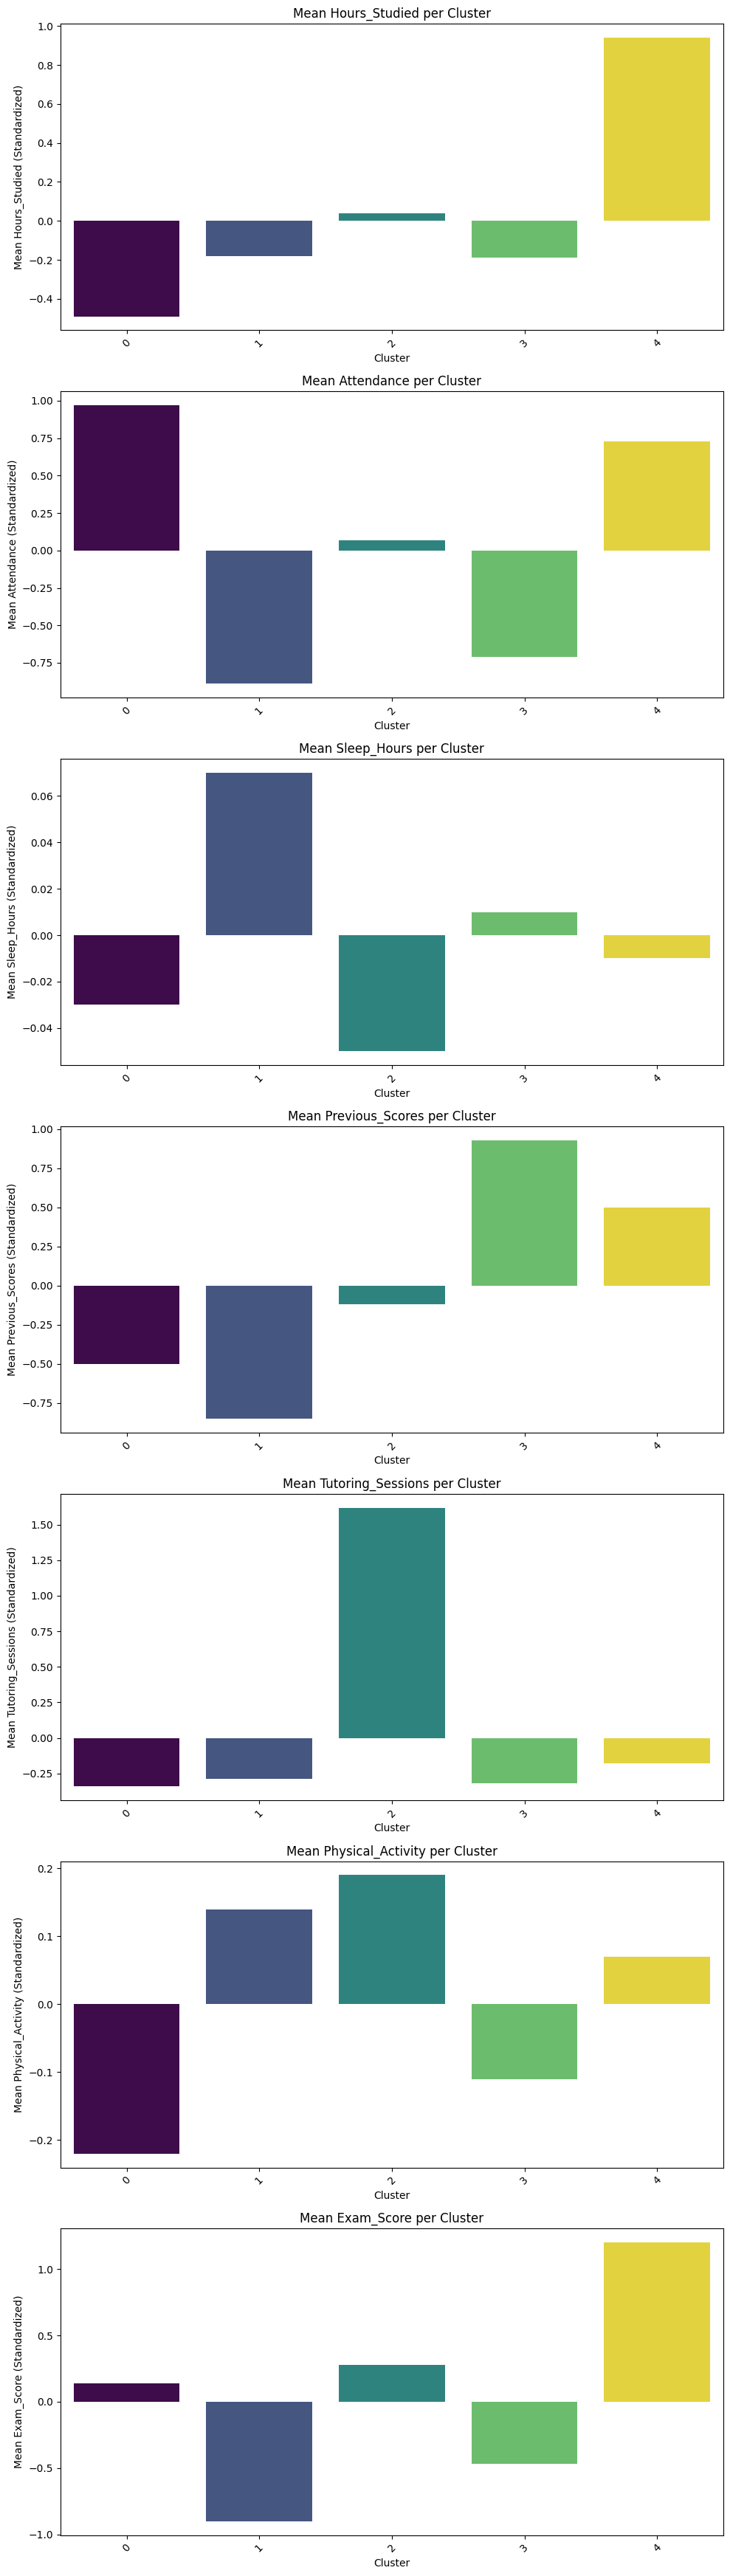

In [ ]:
num_means = df_pronto.groupby('Cluster')[valores_numericos].mean().round(2)

# Plotting numerical feature means for each cluster
fig, axes = plt.subplots(nrows=len(valores_numericos), ncols=1, figsize=(10, 5 * len(valores_numericos)))
axes = axes.flatten() # Flatten in case of single subplot

for i, col in enumerate(valores_numericos):
    sns.barplot(x=num_means.index, y=num_means[col], ax=axes[i], palette='viridis', hue=num_means.index, legend=False)
    axes[i].set_title(f'Mean {col} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(f'Mean {col} (Standardized)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Mapas de calor por cluster


--- Visualizando Distribuição Categórica por Cluster (Heatmaps) ---


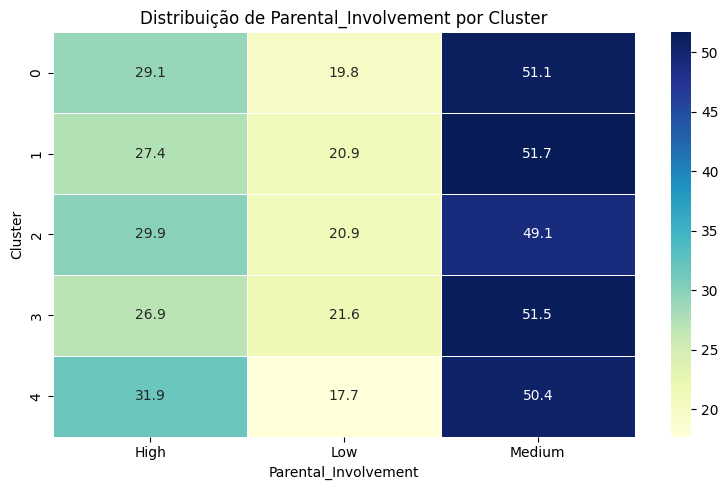

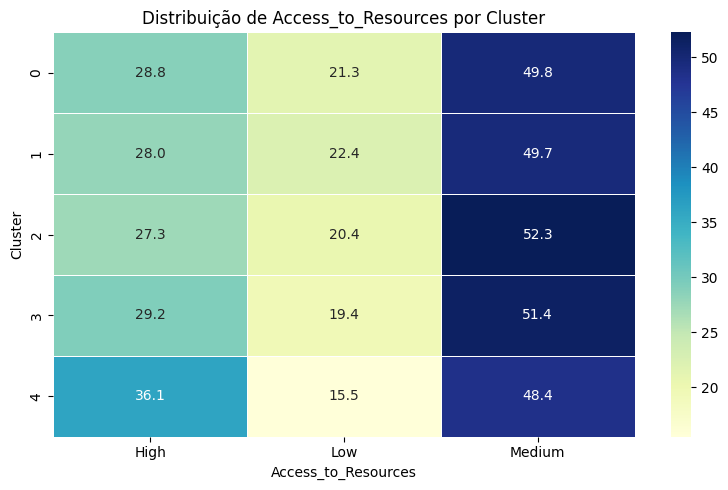

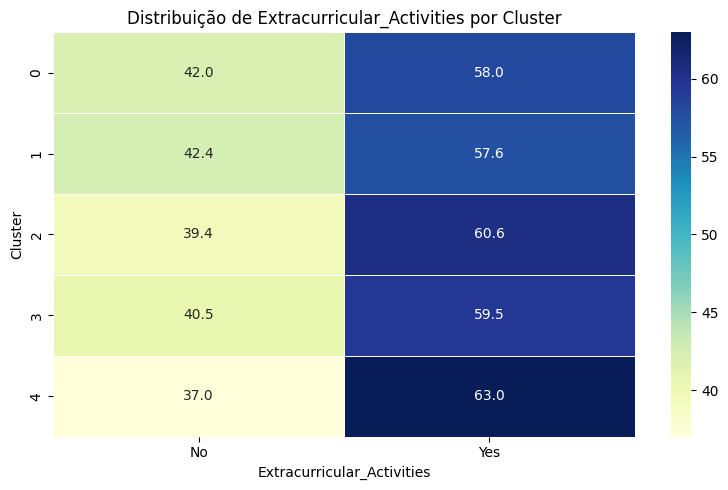

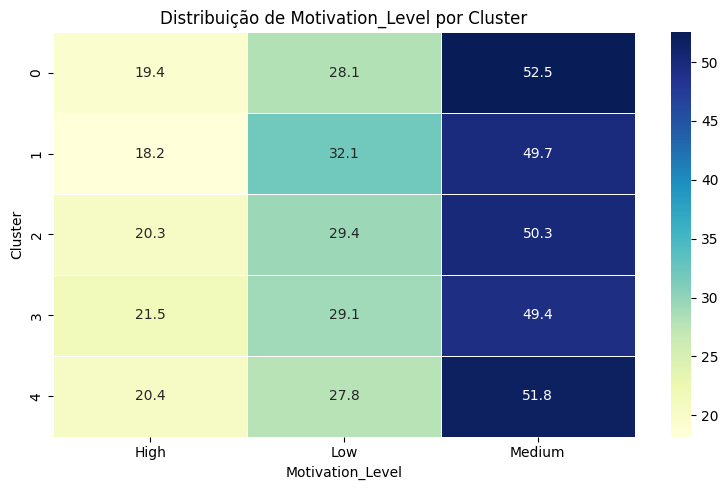

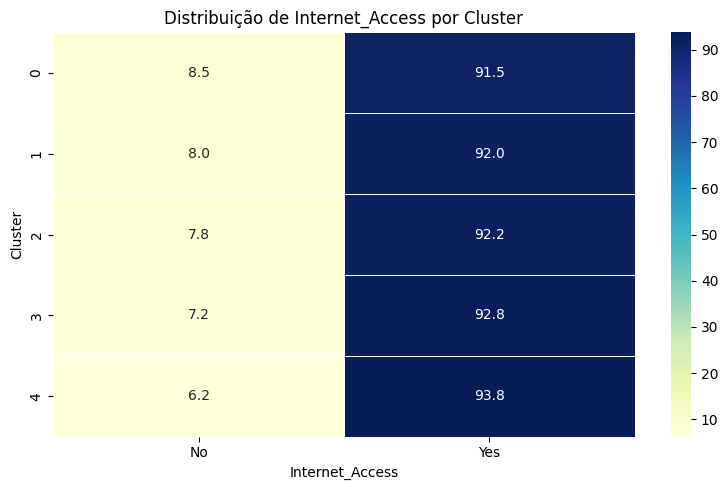

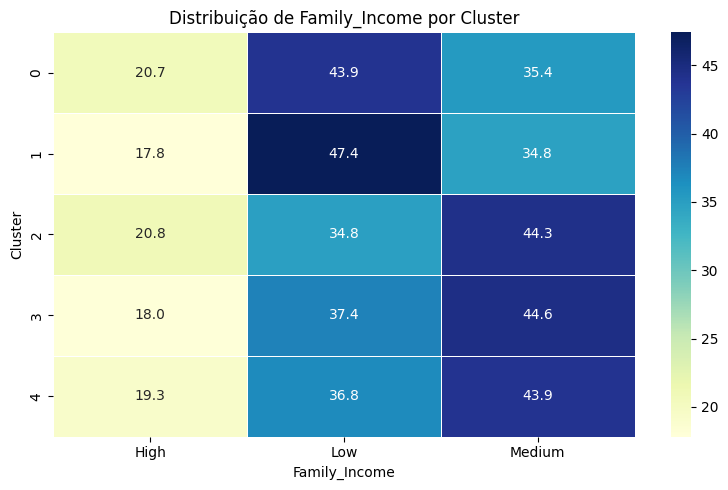

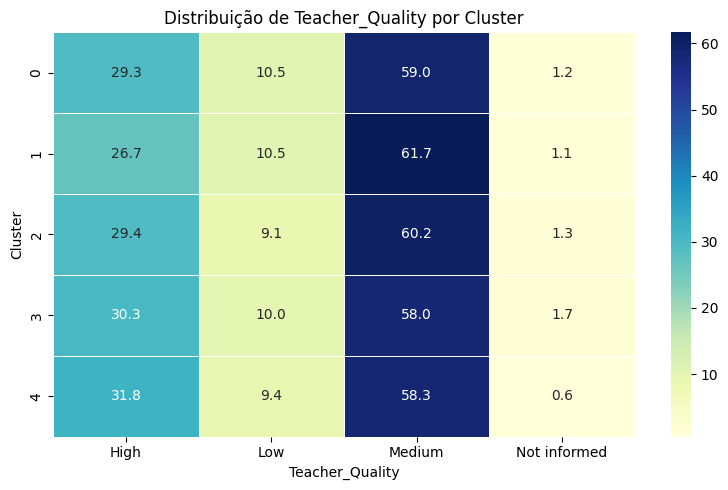

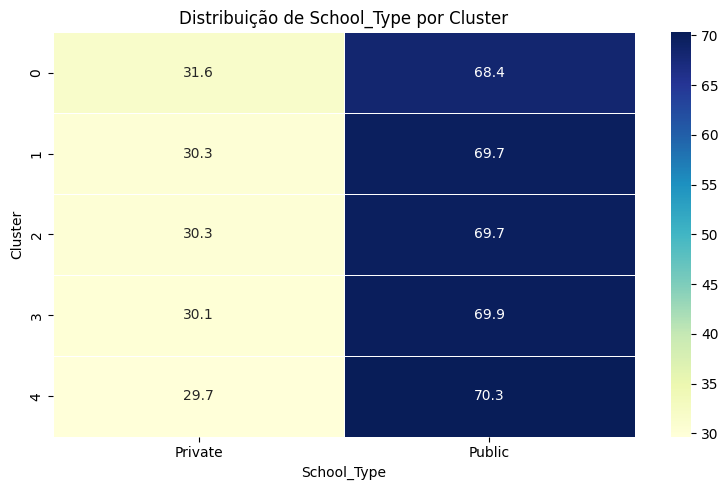

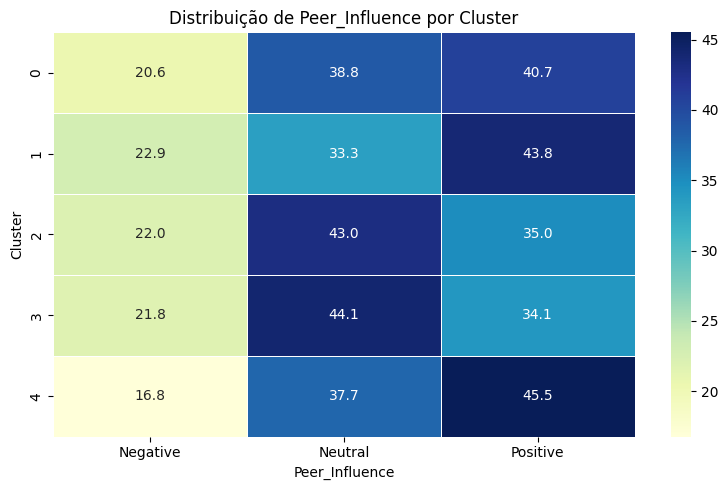

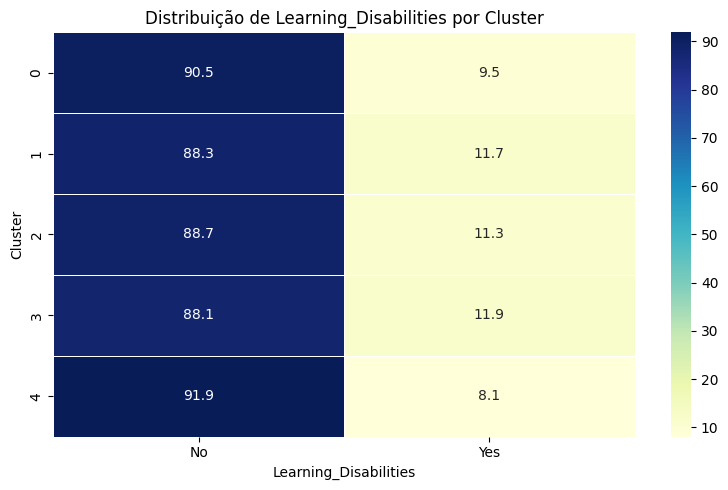

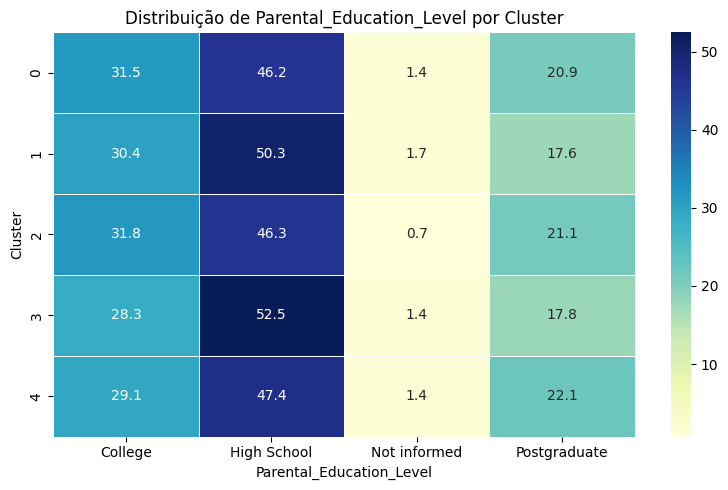

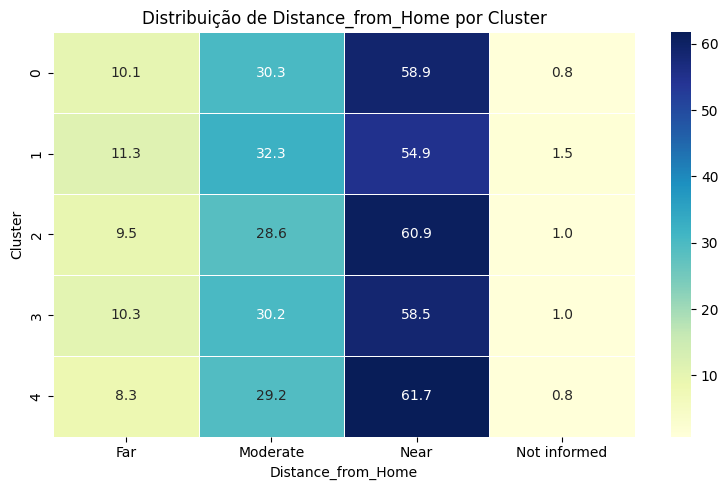

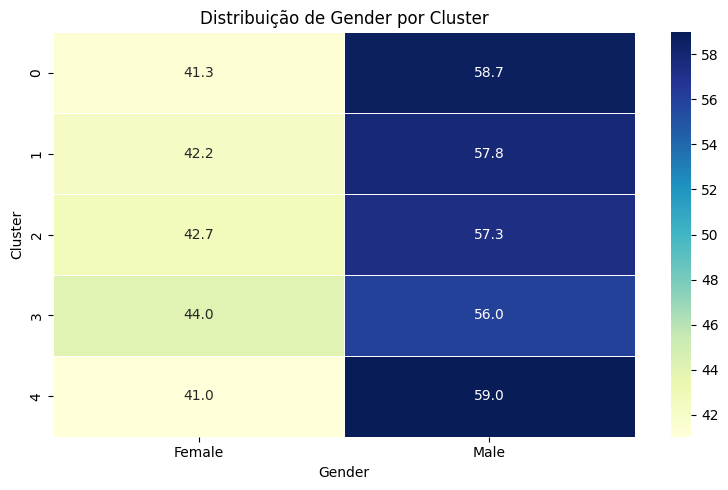

In [ ]:
print("\n--- Visualizando Distribuição Categórica por Cluster (Heatmaps) ---")

for col in valores_categoricos:
    plt.figure(figsize=(8, 5))
    crosstab_norm = pd.crosstab(df_pronto['Cluster'], df_pronto[col], normalize='index') * 100
    sns.heatmap(crosstab_norm, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
    plt.title(f'Distribuição de {col} por Cluster')
    plt.xlabel(col)
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.show()

# Coisas a adicionar

* Nome ou perfil para os cluster(Fazer uma classificação)
* Coeficiente de silhueta(Silhouette Score)
* Índice de Davies-Bouldin: Mede a razão entre a dispersão intra-cluster e a separação inter-cluster.
* Variância explicada pelos 2 componentes: 20.80%
* Tentar PCA com mais componentes para ver se a variância explicada melhora. Explorar outras técnicas de redução de dimensionalidade, como t-SNE ou UMAP, que são mais adequadas para visualizar estruturas complexas de alta dimensão em 2D ou 3D, mesmo que não preservem a distância global como o PCA. Análise de Outliers e Robustez: Investigue se há pontos de dados que não se encaixam bem em nenhum cluster (outliers) e se a formação dos clusters é robusta a pequenas variações nos dados ou nos parâmetros do algoritmo.